In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
from tensorflow.keras.utils import image_dataset_from_directory

In [4]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Data Preparation

In [44]:
training_set = image_dataset_from_directory(
    "train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)
training_set = training_set.map(lambda x, y: (x[..., :3], y))

Found 76515 files belonging to 4 classes.


In [9]:
!nvidia-smi

Sun Nov 16 13:40:47 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.80                 Driver Version: 581.80         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   41C    P8              3W /   50W |    2449MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [45]:
validation_set = image_dataset_from_directory(
    'val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
validation_set = validation_set.map(lambda x, y: (x[..., :3], y))

Found 21861 files belonging to 4 classes.


In [47]:
training_set

<MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [48]:
INPUT_SHAPE = (224, 224, 3)

In [67]:
mobnet = tf.keras.applications.MobileNetV3Small(
    input_shape=INPUT_SHAPE,
    alpha=1.0,
    minimalistic=False,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    classes=1000,
    pooling=None,
    dropout_rate=0.2,
    classifier_activation="softmax",
    include_preprocessing=True,
    # name="MobileNetV3Large",
)

10734624/10734624 [==============================] - 7s 1us/step


In [68]:
model = tf.keras.models.Sequential()

In [69]:
model.add(tf.keras.Input(shape=INPUT_SHAPE))

In [70]:
model.add(mobnet)

In [71]:
model.add(tf.keras.layers.Dense(units = 4,activation='softmax'))

In [72]:
import tensorflow_addons as tfa

metrics_list = [
    "accuracy",
    tfa.metrics.F1Score(num_classes=4, average="macro")
]

In [73]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=metrics_list)

In [74]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3small (Functiona  (None, 1000)             2554968   
 l)                                                              
                                                                 
 dense_3 (Dense)             (None, 4)                 4004      
                                                                 
Total params: 2,558,972
Trainable params: 2,546,860
Non-trainable params: 12,112
_________________________________________________________________


In [75]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=15)

Epoch 1/15
2392/2392 [==============================] - 259s 106ms/step - loss: 1.1271 - accuracy: 0.8630 - f1_score: 0.6531 - val_loss: 0.9634 - val_accuracy: 0.8807 - val_f1_score: 0.6767
Epoch 2/15
2392/2392 [==============================] - 241s 101ms/step - loss: 0.8266 - accuracy: 0.8880 - f1_score: 0.7017 - val_loss: 0.7139 - val_accuracy: 0.9453 - val_f1_score: 0.8994
Epoch 3/15
2392/2392 [==============================] - 243s 101ms/step - loss: 0.6298 - accuracy: 0.9479 - f1_score: 0.9083 - val_loss: 0.5503 - val_accuracy: 0.9534 - val_f1_score: 0.9176
Epoch 4/15
2392/2392 [==============================] - 242s 101ms/step - loss: 0.4913 - accuracy: 0.9525 - f1_score: 0.9176 - val_loss: 0.4429 - val_accuracy: 0.9486 - val_f1_score: 0.9135
Epoch 5/15
2392/2392 [==============================] - 244s 102ms/step - loss: 0.3876 - accuracy: 0.9576 - f1_score: 0.9263 - val_loss: 0.3572 - val_accuracy: 0.9504 - val_f1_score: 0.9156
Epoch 6/15
2392/2392 [============================

In [76]:
model.save("./Trained_Eye_disease_model.h5")


In [78]:
training_history.history

{'loss': [1.1271395683288574,
  0.826614499092102,
  0.6297732591629028,
  0.49126872420310974,
  0.3876049220561981,
  0.3083932399749756,
  0.24880418181419373,
  0.20159912109375,
  0.16703955829143524,
  0.1391722559928894,
  0.11989933252334595,
  0.10523136705160141,
  0.0938604325056076,
  0.08557463437318802,
  0.0780186876654625],
 'accuracy': [0.8629680275917053,
  0.8879958391189575,
  0.9479448199272156,
  0.9524668455123901,
  0.9575638771057129,
  0.9626478552818298,
  0.9664510488510132,
  0.9708030819892883,
  0.9734300374984741,
  0.976893424987793,
  0.9792066812515259,
  0.9809972047805786,
  0.9828007817268372,
  0.984329879283905,
  0.9852447509765625],
 'f1_score': [0.653052568435669,
  0.7016842365264893,
  0.9082950353622437,
  0.9175864458084106,
  0.9262726306915283,
  0.9345967769622803,
  0.9414283037185669,
  0.9491150975227356,
  0.9534162878990173,
  0.9594764709472656,
  0.9634409546852112,
  0.9666002988815308,
  0.9698014259338379,
  0.9725427627563477

In [79]:
#Saving history
import pickle
with open("Training_history.pkl","wb") as f:
    pickle.dump(training_history.history,f)

In [81]:
#Reloading History from pickle
with open('Training_history.pkl', 'rb') as f:
    load_history = pickle.load(f)
print(load_history)

{'loss': [1.1271395683288574, 0.826614499092102, 0.6297732591629028, 0.49126872420310974, 0.3876049220561981, 0.3083932399749756, 0.24880418181419373, 0.20159912109375, 0.16703955829143524, 0.1391722559928894, 0.11989933252334595, 0.10523136705160141, 0.0938604325056076, 0.08557463437318802, 0.0780186876654625], 'accuracy': [0.8629680275917053, 0.8879958391189575, 0.9479448199272156, 0.9524668455123901, 0.9575638771057129, 0.9626478552818298, 0.9664510488510132, 0.9708030819892883, 0.9734300374984741, 0.976893424987793, 0.9792066812515259, 0.9809972047805786, 0.9828007817268372, 0.984329879283905, 0.9852447509765625], 'f1_score': [0.653052568435669, 0.7016842365264893, 0.9082950353622437, 0.9175864458084106, 0.9262726306915283, 0.9345967769622803, 0.9414283037185669, 0.9491150975227356, 0.9534162878990173, 0.9594764709472656, 0.9634409546852112, 0.9666002988815308, 0.9698014259338379, 0.9725427627563477, 0.9741859436035156], 'val_loss': [0.9633921980857849, 0.7139127254486084, 0.550305

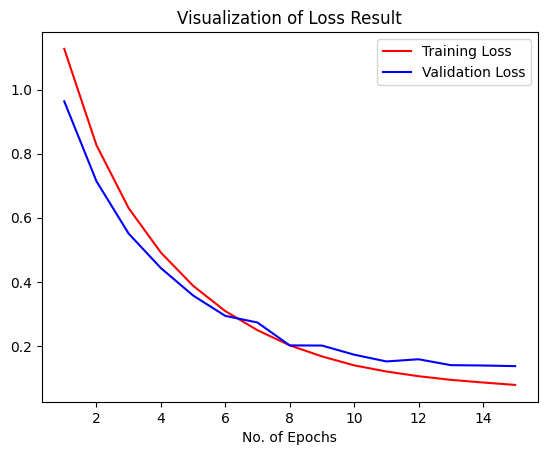

In [82]:
#Loss Visualization
epochs = [i for i in range(1,16)]
plt.plot(epochs,load_history['loss'],color='red',label='Training Loss')
plt.plot(epochs,load_history['val_loss'],color='blue',label='Validation Loss')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Loss Result')
plt.legend()
plt.show()

## Model Evaluation

In [87]:
model = tf.keras.models.load_model('Trained_Eye_disease_model.h5')

In [88]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3small (Functiona  (None, 1000)             2554968   
 l)                                                              
                                                                 
 dense_3 (Dense)             (None, 4)                 4004      
                                                                 
Total params: 2,558,972
Trainable params: 2,546,860
Non-trainable params: 12,112
_________________________________________________________________


In [105]:
test_set = image_dataset_from_directory(
    'test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 10933 files belonging to 4 classes.


In [106]:
test_loss,test_accuracy,f1_score = model.evaluate(test_set)

342/342 [==============================] - 13s 38ms/step - loss: 0.1420 - accuracy: 0.9652 - f1_score: 0.9379


In [107]:
test_loss

0.141950324177742

In [108]:
test_accuracy

0.965242862701416

In [109]:
f1_score

0.9379147291183472

In [110]:
##Computing True labels from test set
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [111]:
true_categories

<tf.Tensor: shape=(10933, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]], dtype=float32)>

In [112]:
Y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

In [113]:
##Computing Predicted labels using test set
predicted_categories = model.predict(test_set)
predicted_categories

342/342 [==============================] - 13s 37ms/step


array([[0.98207456, 0.00485452, 0.00794478, 0.00512618],
       [0.9820679 , 0.00485745, 0.0079468 , 0.00512791],
       [0.9820703 , 0.00485587, 0.00794652, 0.0051273 ],
       ...,
       [0.00328278, 0.0048729 , 0.00761041, 0.9842339 ],
       [0.00328278, 0.0048729 , 0.00761041, 0.9842339 ],
       [0.00328296, 0.00487309, 0.00761098, 0.984233  ]], dtype=float32)

In [114]:
Y_Pred = tf.argmax(predicted_categories,axis=1)
Y_Pred

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

In [115]:
Y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

### 1. Classification Report

In [116]:
from sklearn.metrics import classification_report
print(classification_report(Y_true,Y_Pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3746
           1       0.95      0.95      0.95      1161
           2       0.90      0.80      0.85       887
           3       0.98      0.99      0.98      5139

    accuracy                           0.97     10933
   macro avg       0.95      0.93      0.94     10933
weighted avg       0.96      0.97      0.96     10933



### 2. Confusion Matrix

In [117]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_true,Y_Pred)
cm

array([[3644,   28,   64,   10],
       [  22, 1103,    1,   35],
       [  81,    8,  713,   85],
       [   4,   24,   18, 5093]], dtype=int64)

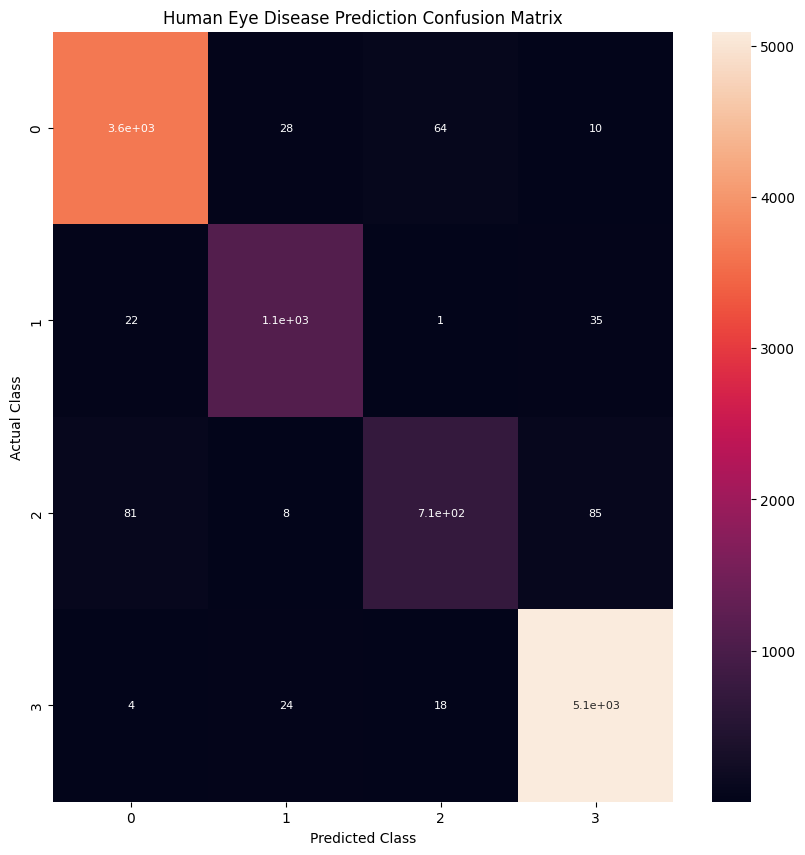

In [118]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,annot_kws={"size":8})
plt.xlabel("Predicted Class",fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("Human Eye Disease Prediction Confusion Matrix",fontsize=12)
plt.show()